# Hybrid Sigma Humidity Tendency With Z-Factors

Create a CMIP7 monthly humidity tendency file (`tnhusscpbl_tavg-al-hxy-u`) on a standard hybrid sigma pressure coordinate. This example reads source data with xarray, defines the vertical coordinate formula terms with CMOR zfactors, and stores surface pressure with the data variable.

In [1]:
from pathlib import Path
import json
import shutil

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "tnhusscpbl_CFmon_MIROC-ES2L_amip_r2i1p1f2_gn_197901-197905.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")

print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(source)


<xarray.Dataset> Size: 7MB
Dimensions:     (time: 5, bnds: 2, lev: 40, lat: 64, lon: 128)
Coordinates:
  * time        (time) float64 40B 15.5 45.0 74.5 105.0 135.5
  * lev         (lev) float64 320B 0.9975 0.9915 0.983 ... 0.0106 0.002905
  * lat         (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon         (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
Dimensions without coordinates: bnds
Data variables:
    time_bnds   (time, bnds) float64 80B 0.0 31.0 31.0 ... 120.0 120.0 151.0
    lev_bnds    (lev, bnds) float64 640B 1.0 0.995 0.995 ... 0.007 0.007 0.0
    p0          float64 8B 1e+05
    a           (lev) float64 320B 0.001113 0.003782 ... 0.0106 0.002905
    b           (lev) float64 320B 0.9964 0.9877 0.9754 0.9595 ... 0.0 0.0 0.0
    ps          (time, lat, lon) float32 164kB 6.951e+04 6.928e+04 ... 1.029e+05
    a_bnds      (lev, bnds) float64 640B 0.0 0.002224 0.002224 ... 0.007 0.0
    b_bnds      (lev, bnds) float64 640B 1.0 0.9928 0.9928 ... 0.0 0.0 0.0
    lat_bnds    (lat, bnds) float64 1kB -90.0 -86.58 -86.58 ... 86.58 86.58 90.0
    lon_bnds    (lon, bnds) float64 2kB -1.406 1.406 1.406 ... 355.8 355.8 358.6
    tnhusscpbl  (time, lev, lat, lon) float32 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           CMIP
    branch_method:         no parent
    creation_date:         2020-08-15T22:41:28Z
    data_specs_version:    01.00.28
    experiment:            AMIP
    experiment_id:         amip
    external_variables:    areacella
    forcing_index:         2
    frequency:             mon
    further_info_url:      https://furtherinfo.es-doc.org/CMIP6.MIROC.MIROC-E...
    grid:                  native atmosphere T42 Gaussian grid
    grid_label:            gn
    history:               2020-08-15T22:41:28Z ; CMOR rewrote data to be con...
    initialization_index:  1
    institution:           JAMSTEC (Japan Agency for Marine-Earth Science and...
    institution_id:        MIROC
    mip_era:               CMIP6
    nominal_resolution:    500 km
    parent_activity_id:    no parent
    parent_experiment_id:  no parent
    physics_index:         1
    product:               model-output
    realization_index:     2
    realm:                 atmos
    source:                MIROC-ES2L (2018): \naerosol: SPRINTARS6.0\natmos:...
    source_id:             MIROC-ES2L
    source_type:           AGCM AER BGC
    sub_experiment:        none
    sub_experiment_id:     none
    table_id:              CFmon
    table_info:            Creation Date:(06 November 2018) MD5:af8da38b788c1...
    title:                 MIROC-ES2L output prepared for CMIP6
    variable_id:           tnhusscpbl
    variant_label:         r2i1p1f2
    license:               CMIP6 model data produced by MIROC is licensed und...
    cmor_version:          3.3.2
    tracking_id:           hdl:21.14100/f575a148-89c0-40d7-bdd5-b67e0f73cf4a

In [3]:
run_dir = Path("output") / "04_hybrid_sigma_humidity_tendency"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": source["time"].attrs.get("calendar", "standard"),
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

lat = source["lat"].values.astype("f8")
lat_bnds = source["lat_bnds"].values.astype("f8")
lon = source["lon"].values.astype("f8")
lon_bnds = source["lon_bnds"].values.astype("f8")
time = source["time"].values.astype("f8")
time_bnds = source["time_bnds"].values.astype("f8")
time_units = source["time"].attrs["units"]

lev = source["lev"].values.astype("f8")
lev_bnds = source["lev_bnds"].values.astype("f8")
a = source["a"].values.astype("f8")
a_bnds = source["a_bnds"].values.astype("f8")
b = source["b"].values.astype("f8")
b_bnds = source["b_bnds"].values.astype("f8")
p0 = np.array([float(source["p0"].values)], dtype="f8")

missing_value = np.float32(1.0e20)
tnhusscpbl_source = source["tnhusscpbl"].values.astype("f4")
tnhusscpbl = np.where(np.isfinite(tnhusscpbl_source), tnhusscpbl_source, missing_value).astype("f4")
ps = source["ps"].values.astype("f4")

print(tnhusscpbl.shape, ps.shape)


(5, 40, 64, 128) (5, 64, 128)


In [4]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_atmos.json")

time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)
lev_id = cmor.axis("standard_hybrid_sigma", coord_vals=lev, cell_bounds=lev_bnds, units="1")
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")

cmor.zfactor(zaxis_id=lev_id, zfactor_name="a", axis_ids=[lev_id], zfactor_values=a, zfactor_bounds=a_bnds)
cmor.zfactor(zaxis_id=lev_id, zfactor_name="b", axis_ids=[lev_id], zfactor_values=b, zfactor_bounds=b_bnds)
cmor.zfactor(zaxis_id=lev_id, zfactor_name="p0", units="Pa", zfactor_values=p0)
ps_id = cmor.zfactor(zaxis_id=lev_id, zfactor_name="ps", axis_ids=[time_id, lat_id, lon_id], units="Pa")

variable_name = "tnhusscpbl_tavg-al-hxy-u"
tnhusscpbl_id = cmor.variable(variable_name, "s-1", [time_id, lev_id, lat_id, lon_id], missing_value=missing_value)
compound_name = ".".join(["atmos"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(tnhusscpbl_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(tnhusscpbl_id, "long_name", "c", long_name)

cmor.write(tnhusscpbl_id, tnhusscpbl)
cmor.write(ps_id, ps, store_with=tnhusscpbl_id)
netcdf_path = Path(cmor.close(tnhusscpbl_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))


output/04_hybrid_sigma_humidity_tendency/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/tnhusscpbl/tavg-al-hxy-u/g999/v20260530/tnhusscpbl_tavg-al-hxy-u_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_197901-197905.nc


In [5]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(ds)

<xarray.Dataset> Size: 7MB
Dimensions:     (time: 5, bnds: 2, lev: 40, lat: 64, lon: 128)
Coordinates:
  * time        (time) float64 40B 15.5 45.0 74.5 105.0 135.5
  * lev         (lev) float64 320B 0.9975 0.9915 0.983 ... 0.0106 0.002905
  * lat         (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon         (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
Dimensions without coordinates: bnds
Data variables:
    time_bnds   (time, bnds) float64 80B 0.0 31.0 31.0 ... 120.0 120.0 151.0
    lev_bnds    (lev, bnds) float64 640B 1.0 0.995 0.995 ... 0.007 0.007 0.0
    p0          float64 8B 1e+05
    a           (lev) float64 320B 0.001113 0.003782 ... 0.0106 0.002905
    b           (lev) float64 320B 0.9964 0.9877 0.9754 0.9595 ... 0.0 0.0 0.0
    ps          (time, lat, lon) float32 164kB 6.951e+04 6.928e+04 ... 1.029e+05
    a_bnds      (lev, bnds) float64 640B 0.0 0.002224 0.002224 ... 0.007 0.0
    b_bnds      (lev, bnds) float64 640B 1.0 0.9928 0.9928 ... 0.0 0.0 0.0
    lat_bnds    (lat, bnds) float64 1kB -90.0 -86.58 -86.58 ... 86.58 86.58 90.0
    lon_bnds    (lon, bnds) float64 2kB -1.406 1.406 1.406 ... 355.8 355.8 358.6
    tnhusscpbl  (time, lev, lat, lon) float32 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            u
    branded_variable:      tnhusscpbl_tavg-al-hxy-u
    branding_suffix:       tavg-al-hxy-u
    creation_date:         2026-05-30T19:33:33Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    external_variables:    areacella
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-30T19:33:33Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    100 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 atmos
    region:                glb
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_atmos.json; Creation Date:(2026-04-21 ...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    variable_id:           tnhusscpbl
    variant_label:         r9i1p1f3
    vertical_label:        al
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1
    tracking_id:           hdl:21.14107/646505af-8ff3-4d2e-bd1b-289a64341682

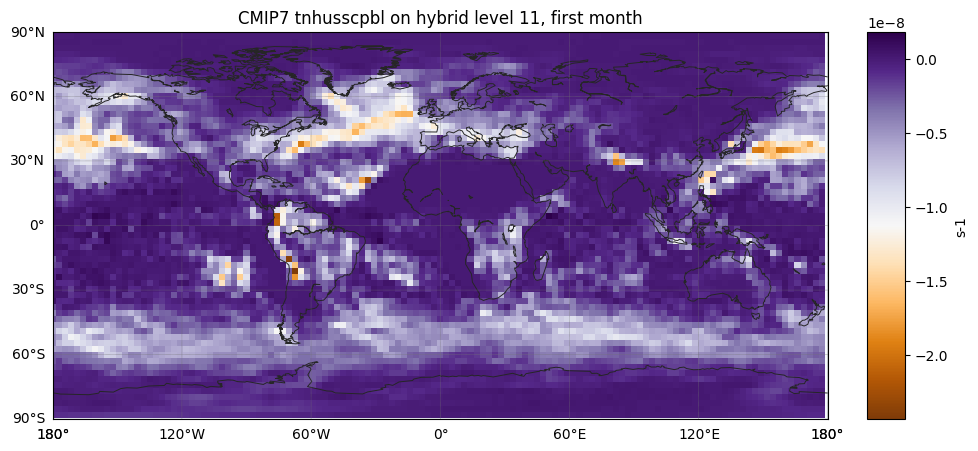

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=-180,
    urcrnrlon=180,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
lon_wrapped = ((ds["lon"].values + 180.0) % 360.0) - 180.0
lon_order = np.argsort(lon_wrapped)
lon_grid, lat_grid = np.meshgrid(lon_wrapped[lon_order], ds["lat"].values)
x, y = map_plot(lon_grid, lat_grid)
field = ds["tnhusscpbl"].isel(time=0, lev=10).values[:, lon_order]
mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="PuOr")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("s-1")
ax.set_title("CMIP7 tnhusscpbl on hybrid level 11, first month")
plt.show()
